In [1]:
import pandas as pd
import numpy as np
#from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
#from sklearn.preprocessing import StandardScaler

# Exo1:
## ACP
En excluant la variable Rating, effectuer une ACP sur les variables restantes. Tracer les graphes suivants :\
• Courbe cumulative de la variance expliquée. Interpréter : a-t-on une bonne représentation ?\
• Nuage des individus projétés sur les 2 premières composantes principales, colorés par rating. Interpréter : peut-on obtenir une bonne prédiction en n’utilisant que ces deux composantes ?\
• Même nuage, colorés selon la qualité de la représentation (cos2). Interpréter : comment lier
cela à la variance expliquée ?

In [5]:
#une méthode pour l'importation des données
google_df=pd.read_csv('google_max_30.csv')
google_df

,Rating,Reviews,Size,Installs,Price,Timestamp,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMMUNICATION,Category_DATING,...,Genres_Puzzle,Genres_Role Playing,Genres_Shopping,Genres_Simulation,Genres_Social,Genres_Sports,Genres_Tools,Genres_Travel & Local,Genres_Video Players & Editors,Genres_infrequent_sklearn
0,4.1,159.0,19000000.0,4.00000,0.0,1.515283e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3.9,967.0,14000000.0,5.69897,0.0,1.515974e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,4.7,87510.0,8700000.0,6.69897,0.0,1.533082e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4.5,215644.0,25000000.0,7.69897,0.0,1.528416e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,4.3,967.0,2800000.0,5.00000,0.0,1.529453e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7718,4.8,44.0,619000.0,3.00000,0.0,1.395533e+09,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7719,4.0,7.0,2600000.0,2.69897,0.0,1.497744e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7720,4.5,38.0,53000000.0,3.69897,0.0,1.500941e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7721,5.0,4.0,3600000.0,2.00000,0.0,1.530835e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
#avec path
file_path='/Users/Yixin/Downloads/google_max_30.csv'
m=pd.read_csv(file_path,header=0)
# header=0 means that the first row contains the column names.
# header=None means pandas will not use any row as the header, 
# and the column names will be assigned default integer values

In [13]:
google_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7723 entries, 0 to 7722
Data columns (total 62 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Rating                             7723 non-null   float64
 1   Reviews                            7723 non-null   float64
 2   Size                               7723 non-null   float64
 3   Installs                           7723 non-null   float64
 4   Price                              7723 non-null   float64
 5   Timestamp                          7723 non-null   float64
 6   Category_BOOKS_AND_REFERENCE       7723 non-null   float64
 7   Category_BUSINESS                  7723 non-null   float64
 8   Category_COMMUNICATION             7723 non-null   float64
 9   Category_DATING                    7723 non-null   float64
 10  Category_EDUCATION                 7723 non-null   float64
 11  Category_FAMILY                    7723 non-null   float

In [14]:
google_df.describe()

,Rating,Reviews,Size,Installs,Price,Timestamp,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMMUNICATION,Category_DATING,...,Genres_Puzzle,Genres_Role Playing,Genres_Shopping,Genres_Simulation,Genres_Social,Genres_Sports,Genres_Tools,Genres_Travel & Local,Genres_Video Players & Editors,Genres_infrequent_sklearn
count,7723.000000,7.723000e+03,7.723000e+03,7723.000000,7723.000000,7.723000e+03,7723.000000,7723.000000,7723.000000,7723.000000,...,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000
mean,4.173935,2.948983e+05,2.297046e+07,5.059810,1.128169,1.509190e+09,0.018646,0.031853,0.027321,0.022401,...,0.013855,0.013337,0.023178,0.023566,0.022919,0.033795,0.081963,0.020588,0.014891,0.192930
std,0.544638,1.863933e+06,2.344963e+07,1.608296,17.408036,3.595212e+07,0.135279,0.175620,0.163028,0.147992,...,0.116895,0.114720,0.150477,0.151702,0.149654,0.180713,0.274326,0.142009,0.121123,0.394624
min,1.000000,1.000000e+00,8.500000e+03,0.000000,0.000000,1.274400e+09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,1.075000e+02,5.300000e+06,4.000000,0.000000,1.501286e+09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.300000,2.332000e+03,1.400000e+07,5.000000,0.000000,1.526342e+09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.500000,3.905300e+04,3.300000e+07,6.000000,0.000000,1.531786e+09,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,4.489389e+07,1.000000e+08,9.000000,400.000000,1.533686e+09,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
data=google_df.iloc[:,1:] #exclure Rating
rating=google_df.Rating.values

In [16]:
rating

array([4.1, 3.9, 4.7, ..., 4.5, 5. , 4.5])

In [17]:
data-=data.mean()#centrer
data/=data.std()#réduire

In [18]:
data

,Reviews,Size,Installs,Price,Timestamp,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMMUNICATION,Category_DATING,Category_EDUCATION,...,Genres_Puzzle,Genres_Role Playing,Genres_Shopping,Genres_Simulation,Genres_Social,Genres_Sports,Genres_Tools,Genres_Travel & Local,Genres_Video Players & Editors,Genres_infrequent_sklearn
0,-0.158128,-0.169319,-0.658964,-0.064807,0.169481,-0.137831,-0.181374,-0.167585,-0.151364,-0.120196,...,-0.118522,-0.116255,-0.154027,-0.155344,-0.153144,-0.18701,-0.298779,-0.144976,-0.122938,2.045160
1,-0.157694,-0.382541,0.397415,-0.064807,0.188707,-0.137831,-0.181374,-0.167585,-0.151364,-0.120196,...,-0.118522,-0.116255,-0.154027,-0.155344,-0.153144,-0.18701,-0.298779,-0.144976,-0.122938,2.045160
2,-0.111264,-0.608558,1.019191,-0.064807,0.664540,-0.137831,-0.181374,-0.167585,-0.151364,-0.120196,...,-0.118522,-0.116255,-0.154027,-0.155344,-0.153144,-0.18701,-0.298779,-0.144976,-0.122938,2.045160
3,-0.042520,0.086549,1.640967,-0.064807,0.534767,-0.137831,-0.181374,-0.167585,-0.151364,-0.120196,...,-0.118522,-0.116255,-0.154027,-0.155344,-0.153144,-0.18701,-0.298779,-0.144976,-0.122938,2.045160
4,-0.157694,-0.860161,-0.037188,-0.064807,0.563605,-0.137831,-0.181374,-0.167585,-0.151364,-0.120196,...,-0.118522,-0.116255,-0.154027,-0.155344,-0.153144,-0.18701,-0.298779,-0.144976,-0.122938,2.045160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7718,-0.158189,-0.953169,-1.280741,-0.064807,-3.161349,7.254318,-0.181374,-0.167585,-0.151364,-0.120196,...,-0.118522,-0.116255,-0.154027,-0.155344,-0.153144,-0.18701,-0.298779,-0.144976,-0.122938,-0.488896
7719,-0.158209,-0.868690,-1.467914,-0.064807,-0.318368,-0.137831,-0.181374,-0.167585,-0.151364,-0.120196,...,-0.118522,-0.116255,-0.154027,-0.155344,-0.153144,-0.18701,-0.298779,-0.144976,-0.122938,-0.488896
7720,-0.158193,1.280598,-0.846138,-0.064807,-0.229449,-0.137831,-0.181374,-0.167585,-0.151364,-0.120196,...,-0.118522,-0.116255,-0.154027,-0.155344,-0.153144,-0.18701,-0.298779,-0.144976,-0.122938,-0.488896
7721,-0.158211,-0.826045,-1.902517,-0.064807,0.602057,-0.137831,-0.181374,-0.167585,-0.151364,-0.120196,...,-0.118522,-0.116255,-0.154027,-0.155344,-0.153144,-0.18701,-0.298779,-0.144976,-0.122938,-0.488896


In [50]:
acp=PCA()
acp.fit(data)

PCA()

In [83]:
plt.rcParams['figure.figsize'] = (15, 7)  # Taille par défaut de la figure
plt.rcParams['axes.titlesize']=18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['legend.fontsize']=10
plt.rcParams['legend.title_fontsize'] = 12


array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60])

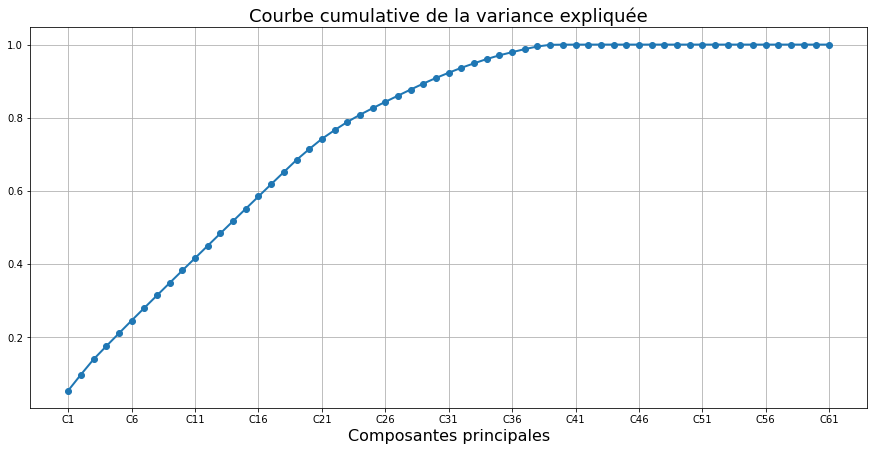

In [92]:
plt.plot(np.cumsum(acp.explained_variance_ratio_), '-o')
x=np.arange(0,len(acp.explained_variance_ratio_),5)
plt.grid()
plt.title('Courbe cumulative de la variance expliquée')
plt.xlabel('Composantes principales')
C=[f'C{5*i+1}' for i in range(len(x))] #f'C{i+1}' 使用了 f 字符串（格式化字符串
plt.xticks(x,C)


<Figure size 1440x720 with 0 Axes>

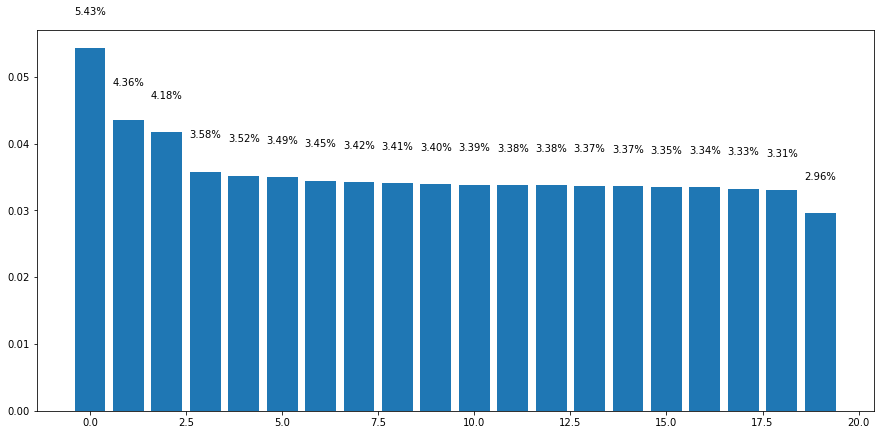

<Figure size 1440x720 with 0 Axes>

In [113]:
#Pour vérifier c'est une bonne interprétation.
plt.bar(range(20), acp.explained_variance_ratio_[:20])
for i, var in enumerate(acp.explained_variance_ratio_[:20]):
    plt.text(i, var + 0.005,f'{var:.2%}', ha='center',size='10')
plt.figure(figsize=(20, 10))

on voit que les deux première CP décrivent moins de 20% de la variance -> ne pas bien

In [75]:
len(acp.explained_variance_ratio_)

61

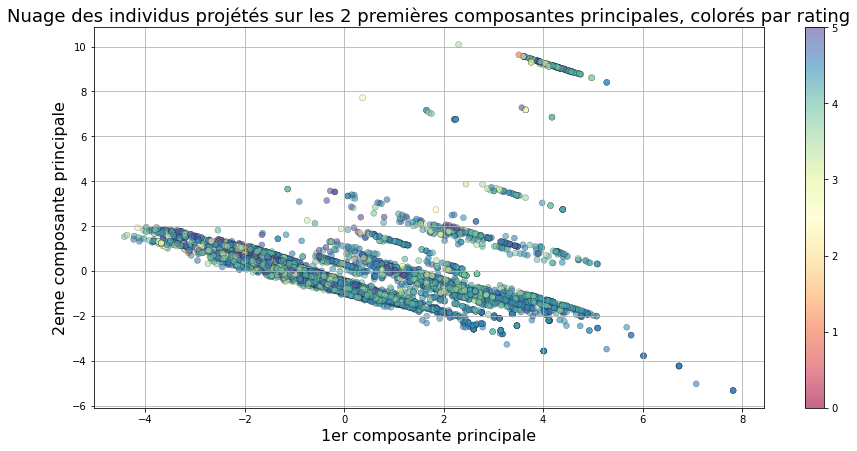

In [150]:
cp=acp.transform(data)

plt.title('Nuage des individus projétés sur les 2 premières composantes principales, colorés par rating')
plt.xlabel('1er composante principale')
plt.ylabel('2eme composante principale')
r=plt.scatter(cp[:, 0], cp[:, 1], c=rating, cmap='Spectral', vmin=0, vmax=5, edgecolor='k', linewidth=0.3, alpha=0.6)
plt.grid()
plt.colorbar()

In [ ]:
plt.legend(handles=r.legend_elements()[0],title='Rating',labels=r.legend_elements()[1])

In [39]:
r.legend_elements()

([<matplotlib.lines.Line2D at 0x7f78a22d8430>,
 ['$\\mathdefault{1.0}$',
  '$\\mathdefault{1.5}$',
  '$\\mathdefault{2.0}$',
  '$\\mathdefault{2.5}$',
  '$\\mathdefault{3.0}$',
  '$\\mathdefault{3.5}$',
  '$\\mathdefault{4.0}$',
  '$\\mathdefault{4.5}$',
  '$\\mathdefault{5.0}$'])

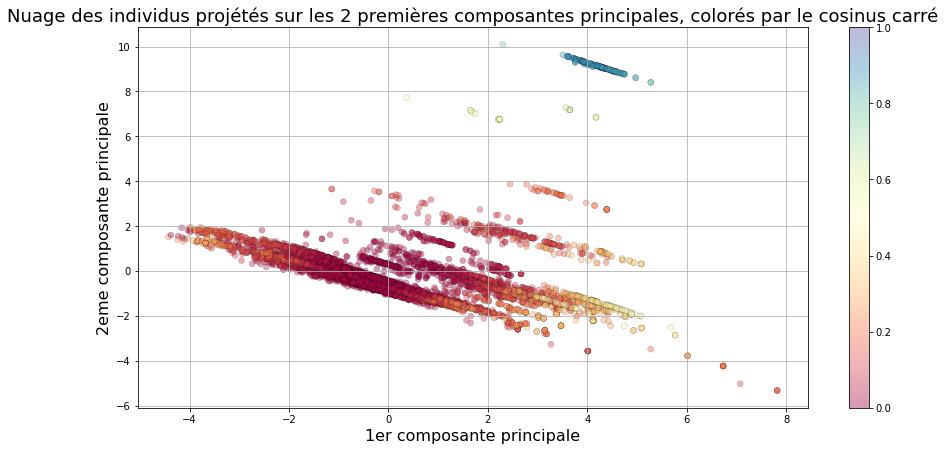

In [153]:
#pour cos^2
numerateur = np.sum(cp[:, :2] ** 2, axis=1)
normes2 = np.sum(cp ** 2, axis=1)
cosines2 = numerateur / normes2

plt.title('Nuage des individus projétés sur les 2 premières composantes principales, colorés par le cosinus carré')
plt.xlabel('1er composante principale')
plt.ylabel('2eme composante principale')
r=plt.scatter(cp[:, 0], cp[:, 1], c=cosines2, cmap='Spectral', vmin=0, vmax=1, edgecolor='k', linewidth=0.3, alpha=0.4)
plt.grid()
plt.colorbar()

On trouve que la plupart des points sont colorés en rouge, c'est à dire que la cosines carré de ces points sont proches de 0, donc c'est pas une bonne interprétation

On concentre entre la partie en haut:

(8.0, 10.5)

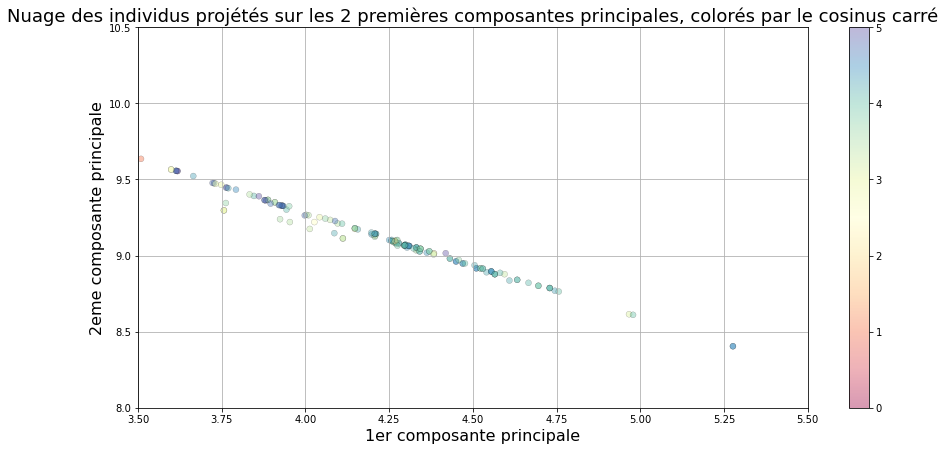

In [162]:
plt.title('Nuage des individus projétés sur les 2 premières composantes principales, colorés par le cosinus carré')
plt.xlabel('1er composante principale')
plt.ylabel('2eme composante principale')
r=plt.scatter(cp[:, 0], cp[:, 1], c=rating, cmap='Spectral', vmin=0, vmax=5, edgecolor='k', linewidth=0.3, alpha=0.4)
plt.grid()
plt.colorbar()
plt.xlim(3.5, 5.5)
plt.ylim(8, 10.5)

# Exo2
## AFD
• Créer une variable target en divisant les applications ayant rating < 4.1, celles ayant entre 4.1 et 4.4, et celles ayant > 4.4. Appliquer une AFD linéaire aux mêmes données, en utilisant target come variable de référence. Combien d’axes factoriels obtient-on ? Pourquoi ?\
• Tracer une nuage colorée selon target. A-t-on une bonne séparation des trois classes ?\
• Calculer l’accuracy de cette méthode de classification et la matrice de confusion. Est-ce
satisfaisant ?\